# Med-MICN on COVID-CT

Run this notebook top-to-bottom. It adapts the Med-MICN concept-based model in this repository to `/Users/samehissa/Downloads/COVID-CT-Dataset-master` using the uploaded concept file `/Users/samehissa/Downloads/covid_ct_concepts_completed.csv`.

The last cells report test-set classification metrics, concept prediction metrics, confusion matrix, and example neural-symbolic explanations.

## 1. Dependencies

Run the install line once if any imports fail. On a machine with CUDA, install the PyTorch build recommended for your CUDA version from pytorch.org instead.

In [1]:
# Uncomment and run once if needed:
# %pip install -r requirements-covid-ct.txt


## 2. Imports and Configuration

In [2]:
from pathlib import Path
import os
Path('outputs/matplotlib_cache').mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(Path('outputs/matplotlib_cache').resolve()))
import random
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt

from models import Neural_Concat_Model
import torch_explain as te
from torch_explain.nn.concepts import ConceptReasoningLayer

SEED = 42
DATA_ROOT = Path('/Users/samehissa/Downloads/COVID-CT-Dataset-master')
CONCEPT_CSV = Path('/Users/samehissa/Downloads/covid_ct_concepts_completed.csv')
OUTPUT_DIR = Path('outputs/covid_ct_med_micn')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training controls. Use fewer epochs for a smoke test, more for final results.
BACKBONE = 'RN50'  # options: 'RN50', 'DenseNet', 'vgg'
USE_PRETRAINED = True
FREEZE_BACKBONE = False
EMBEDDING_SIZE = 8
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = None  # None chooses the repo's default per backbone
CONCEPT_LOSS_WEIGHT = 0.1
NEURAL_LOSS_WEIGHT = 0.1
CONCEPT_TASK_LOSS_WEIGHT = 0.0  # keep 0.0 to match the original repo behavior
NUM_WORKERS = 0  # safest for notebooks/macOS

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('Device:', DEVICE)
print('Torch:', torch.__version__)
print('Data root exists:', DATA_ROOT.exists())
print('Concept CSV exists:', CONCEPT_CSV.exists())

/Users/samehissa/Downloads/NeurIPS24-Med_MICN-main/.venv-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Torch: 2.2.2
Data root exists: True
Concept CSV exists: True


## 3. Load and Validate the Concept CSV

In [3]:
df = pd.read_csv(CONCEPT_CSV)
concept_cols = [c for c in df.columns if c.startswith('concept_') and c.endswith('_label')]
required_cols = {'image_id', 'file_name', 'class_name', 'true_label', 'split', 'image_path'}
missing_cols = required_cols.difference(df.columns)
assert not missing_cols, f'Missing columns in concept CSV: {missing_cols}'
assert concept_cols, 'No concept columns found. Expected columns like concept_*_label.'

def resolve_image_path(row):
    original = Path(str(row['image_path']))
    if original.exists():
        return original
    folder = 'CT_COVID' if int(row['true_label']) == 1 else 'CT_NonCOVID'
    candidate = DATA_ROOT / 'Images-processed' / folder / str(row['file_name'])
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f'Could not find image for row: {row.to_dict()}')

df['resolved_path'] = df.apply(resolve_image_path, axis=1).astype(str)
df['true_label'] = df['true_label'].astype(int)
for col in concept_cols:
    df[col] = df[col].astype(float)

concept_names = [
    c.removeprefix('concept_').removesuffix('_label').replace('_', ' ')
    for c in concept_cols
]

print('Rows:', len(df))
print('Concept count:', len(concept_cols))
print('Concepts:')
for name in concept_names:
    print(' -', name)
print('\nSplit x class counts:')
display(pd.crosstab(df['split'], df['class_name']))
print('\nConcept positive counts:')
display(df[concept_cols].sum().sort_values(ascending=False).to_frame('positive_count'))
display(df.head())

Rows: 746
Concept count: 8
Concepts:
 - peripheral ground glass opacities
 - bilateral involvement
 - multilobar distribution
 - crazy paving pattern
 - absence of lobar consolidation
 - localized or diffuse presentation
 - increased density in the lung
 - ground glass appearance

Split x class counts:


class_name,COVID,NonCOVID
split,,
test,98,105
train,191,234
val,60,58



Concept positive counts:


,positive_count
concept_absence_of_lobar_consolidation_label,726.0
concept_increased_density_in_the_lung_label,587.0
concept_multilobar_distribution_label,582.0
concept_localized_or_diffuse_presentation_label,572.0
concept_ground_glass_appearance_label,566.0
concept_peripheral_ground_glass_opacities_label,528.0
concept_bilateral_involvement_label,512.0
concept_crazy_paving_pattern_label,56.0


,image_id,file_name,class_name,true_label,split,image_path,concept_peripheral_ground_glass_opacities_label,concept_bilateral_involvement_label,concept_multilobar_distribution_label,concept_crazy_paving_pattern_label,concept_absence_of_lobar_consolidation_label,concept_localized_or_diffuse_presentation_label,concept_increased_density_in_the_lung_label,concept_ground_glass_appearance_label,resolved_path
0,covid_2019_novel_Coronavirus_severe_adult_resp...,2019-novel-Coronavirus-severe-adult-respirator...,COVID,1,test,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...
1,covid_2019_novel_Coronavirus_severe_adult_resp...,2019-novel-Coronavirus-severe-adult-respirator...,COVID,1,test,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...
2,covid_2019_novel_Coronavirus_severe_adult_resp...,2019-novel-Coronavirus-severe-adult-respirator...,COVID,1,test,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...
3,covid_2020_03_12_20034686_p17_91_1,2020.03.12.20034686-p17-91-1.png,COVID,1,test,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...
4,covid_2020_03_12_20034686_p17_91_2,2020.03.12.20034686-p17-91-2.png,COVID,1,test,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,/Users/samehissa/Downloads/COVID-CT-Dataset-ma...


## 4. Dataset and Dataloaders

In [4]:
class CovidCTConceptDataset(Dataset):
    def __init__(self, frame, concept_columns, transform=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.concept_columns = list(concept_columns)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = row['resolved_path']
        image = Image.open(path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(int(row['true_label']), dtype=torch.long)
        concepts = torch.tensor(row[self.concept_columns].to_numpy(dtype=np.float32), dtype=torch.float32)
        return path, image, label, concepts

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda tensor: tensor.float() + 1e-6 if tensor.std() == 0 else tensor),
    normalize,
])
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda tensor: tensor.float() + 1e-6 if tensor.std() == 0 else tensor),
    normalize,
])

train_df = df[df['split'].str.lower() == 'train'].copy()
val_df = df[df['split'].str.lower().isin(['val', 'valid', 'validation'])].copy()
test_df = df[df['split'].str.lower() == 'test'].copy()
assert len(train_df) and len(val_df) and len(test_df), 'Expected non-empty train/val/test splits.'

train_loader = DataLoader(
    CovidCTConceptDataset(train_df, concept_cols, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)
val_loader = DataLoader(
    CovidCTConceptDataset(val_df, concept_cols, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)
test_loader = DataLoader(
    CovidCTConceptDataset(test_df, concept_cols, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)

print('Train/val/test:', len(train_df), len(val_df), len(test_df))
paths, images, labels, concepts = next(iter(train_loader))
print('Image batch:', tuple(images.shape))
print('Label batch:', tuple(labels.shape), labels[:8].tolist())
print('Concept batch:', tuple(concepts.shape))

Train/val/test: 425 118 203
Image batch: (16, 3, 224, 224)
Label batch: (16,) [0, 1, 1, 1, 0, 1, 0, 0]
Concept batch: (16, 8)


## 5. Build the Med-MICN Model

In [5]:
def _load_torchvision_backbone(name, pretrained=True):
    name = name.lower()
    try:
        if name == 'rn50':
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            return models.resnet50(weights=weights)
        if name == 'densenet':
            weights = models.DenseNet169_Weights.DEFAULT if pretrained else None
            return models.densenet169(weights=weights)
        if name == 'vgg':
            weights = models.VGG16_Weights.DEFAULT if pretrained else None
            return models.vgg16(weights=weights)
    except Exception as exc:
        if pretrained:
            print(f'Could not load pretrained {name} weights: {exc}')
            print('Falling back to randomly initialized weights. Set USE_PRETRAINED=False to avoid this message.')
            return _load_torchvision_backbone(name, pretrained=False)
        raise

    # Fallback for older torchvision versions.
    if name == 'rn50':
        return models.resnet50(pretrained=pretrained)
    if name == 'densenet':
        return models.densenet169(pretrained=pretrained)
    if name == 'vgg':
        return models.vgg16(pretrained=pretrained)
    raise ValueError(f'Unknown BACKBONE={name!r}. Use RN50, DenseNet, or vgg.')

def build_med_micn(backbone_name, n_concepts, embedding_size, pretrained=True, freeze_backbone=False):
    backbone = _load_torchvision_backbone(backbone_name, pretrained=pretrained)
    if freeze_backbone:
        for parameter in backbone.parameters():
            parameter.requires_grad = False

    # The original repo uses the ImageNet classifier output as a 1000-dimensional feature vector.
    feature_size = 1000
    if backbone_name.lower() == 'densenet':
        concept_hidden = 128
        fused_hidden = 64
        default_lr = 1e-4
    elif backbone_name.lower() == 'vgg':
        concept_hidden = 10
        fused_hidden = 1000
        default_lr = 5e-6
    else:
        concept_hidden = 10
        fused_hidden = 1000
        default_lr = 5e-5

    concept_encoder = nn.Sequential(
        nn.Linear(feature_size, concept_hidden),
        nn.LeakyReLU(),
        te.nn.ConceptEmbedding(concept_hidden, n_concepts, embedding_size),
    )
    task_neural_predictor = ConceptReasoningLayer(embedding_size, 2)

    # Use raw logits here because CrossEntropyLoss expects logits.
    task_predictor = nn.Sequential(
        nn.Linear(n_concepts * embedding_size + feature_size, fused_hidden),
        nn.LeakyReLU(),
        nn.Dropout(0.2),
        nn.Linear(fused_hidden, 2),
    )
    task_concept_predictor = nn.Linear(n_concepts * embedding_size, 2)

    model = Neural_Concat_Model(
        backbone,
        concept_encoder,
        task_neural_predictor,
        task_predictor,
        task_concept_predictor,
    )
    return model, default_lr

model, default_lr = build_med_micn(
    BACKBONE,
    n_concepts=len(concept_cols),
    embedding_size=EMBEDDING_SIZE,
    pretrained=USE_PRETRAINED,
    freeze_backbone=FREEZE_BACKBONE,
)
model = model.to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE or default_lr)

task_loss_fn = nn.CrossEntropyLoss()
concept_loss_fn = nn.BCELoss()
neural_loss_fn = nn.BCELoss()
concept_task_loss_fn = nn.CrossEntropyLoss()

print(model.__class__.__name__)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))
print('Learning rate:', optimizer.param_groups[0]['lr'])

Neural_Concat_Model
Trainable parameters: 26635779
Learning rate: 5e-05


## 6. Metric and Training Helpers

In [6]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def compute_binary_metrics(y_true, y_pred, y_score, prefix=''):
    return {
        f'{prefix}accuracy': accuracy_score(y_true, y_pred),
        f'{prefix}f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}auc': safe_auc(y_true, y_score),
    }

@torch.no_grad()
def evaluate(model, loader, split_name='val'):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    y_neural_pred, y_neural_score = [], []
    concept_true, concept_pred = [], []
    losses = []

    for paths, images, labels, concepts in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        concepts = concepts.to(DEVICE)

        _, task_logits, neural_probs, concept_embeddings, concept_probs, concept_task_logits = model(images)
        task_loss = task_loss_fn(task_logits, labels)
        concept_loss = concept_loss_fn(concept_probs, concepts)
        neural_targets = F.one_hot(labels, num_classes=2).float()
        neural_loss = neural_loss_fn(neural_probs, neural_targets)
        concept_task_loss = concept_task_loss_fn(concept_task_logits, labels)
        loss = (
            task_loss
            + CONCEPT_LOSS_WEIGHT * concept_loss
            + NEURAL_LOSS_WEIGHT * neural_loss
            + CONCEPT_TASK_LOSS_WEIGHT * concept_task_loss
        )
        losses.append(float(loss.detach().cpu()))

        probs = torch.softmax(task_logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        neural_preds = torch.argmax(neural_probs, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_score.extend(probs[:, 1].cpu().numpy().tolist())
        y_neural_pred.extend(neural_preds.cpu().numpy().tolist())
        y_neural_score.extend(neural_probs[:, 1].cpu().numpy().tolist())
        concept_true.append(concepts.cpu().numpy())
        concept_pred.append((concept_probs.cpu().numpy() >= 0.5).astype(int))

    concept_true = np.vstack(concept_true)
    concept_pred = np.vstack(concept_pred)
    metrics = {'split': split_name, 'loss': float(np.mean(losses))}
    metrics.update(compute_binary_metrics(y_true, y_pred, y_score, prefix='task_'))
    metrics.update(compute_binary_metrics(y_true, y_neural_pred, y_neural_score, prefix='neural_'))
    metrics['concept_accuracy'] = float((concept_true == concept_pred).mean())
    metrics['concept_f1_micro'] = f1_score(concept_true.ravel(), concept_pred.ravel(), average='micro', zero_division=0)
    metrics['concept_f1_macro'] = f1_score(concept_true.ravel(), concept_pred.ravel(), average='macro', zero_division=0)
    return metrics, np.asarray(y_true), np.asarray(y_pred), np.asarray(y_score), concept_true, concept_pred

def train_one_epoch(model, loader):
    model.train()
    losses = []
    for paths, images, labels, concepts in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        concepts = concepts.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        _, task_logits, neural_probs, concept_embeddings, concept_probs, concept_task_logits = model(images)

        task_loss = task_loss_fn(task_logits, labels)
        concept_loss = concept_loss_fn(concept_probs, concepts)
        neural_targets = F.one_hot(labels, num_classes=2).float()
        neural_loss = neural_loss_fn(neural_probs, neural_targets)
        concept_task_loss = concept_task_loss_fn(concept_task_logits, labels)
        loss = (
            task_loss
            + CONCEPT_LOSS_WEIGHT * concept_loss
            + NEURAL_LOSS_WEIGHT * neural_loss
            + CONCEPT_TASK_LOSS_WEIGHT * concept_task_loss
        )

        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses))

## 7. Train and Select the Best Validation Checkpoint

In [7]:
history = []
best_val_f1 = -1.0
best_ckpt_path = OUTPUT_DIR / 'best_model.pt'

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    train_metrics, *_ = evaluate(model, train_loader, split_name='train')
    val_metrics, *_ = evaluate(model, val_loader, split_name='val')

    row = {'epoch': epoch, 'train_epoch_loss': train_loss, **train_metrics, **{f'val_{k}': v for k, v in val_metrics.items() if k != 'split'}}
    history.append(row)

    improved = val_metrics['task_f1_macro'] > best_val_f1
    if improved:
        best_val_f1 = val_metrics['task_f1_macro']
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_f1': best_val_f1,
                'config': {
                    'backbone': BACKBONE,
                    'embedding_size': EMBEDDING_SIZE,
                    'concept_cols': concept_cols,
                    'concept_names': concept_names,
                },
            },
            best_ckpt_path,
        )

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_metrics['task_accuracy']:.3f} | "
        f"val_acc={val_metrics['task_accuracy']:.3f} | "
        f"val_f1={val_metrics['task_f1_macro']:.3f} | "
        f"concept_acc={val_metrics['concept_accuracy']:.3f}" +
        (' *' if improved else '')
    )

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / 'training_history.csv'
history_df.to_csv(history_path, index=False)
print('Saved history to:', history_path)
print('Best checkpoint:', best_ckpt_path)

Epoch 001/20 | train_loss=0.7442 | train_acc=0.694 | val_acc=0.551 | val_f1=0.482 | concept_acc=0.392 *


Epoch 002/20 | train_loss=0.4912 | train_acc=0.873 | val_acc=0.602 | val_f1=0.586 | concept_acc=0.457 *


Epoch 003/20 | train_loss=0.2965 | train_acc=0.979 | val_acc=0.686 | val_f1=0.686 | concept_acc=0.490 *


Epoch 004/20 | train_loss=0.2047 | train_acc=0.995 | val_acc=0.703 | val_f1=0.702 | concept_acc=0.523 *


Epoch 005/20 | train_loss=0.1680 | train_acc=0.995 | val_acc=0.695 | val_f1=0.695 | concept_acc=0.553


...

Epoch 016/20 | train_loss=0.1290 | train_acc=0.998 | val_acc=0.678 | val_f1=0.676 | concept_acc=0.801


Epoch 017/20 | train_loss=0.1461 | train_acc=0.991 | val_acc=0.695 | val_f1=0.689 | concept_acc=0.810


Epoch 018/20 | train_loss=0.1437 | train_acc=0.993 | val_acc=0.754 | val_f1=0.754 | concept_acc=0.818 *


Epoch 019/20 | train_loss=0.1629 | train_acc=0.993 | val_acc=0.686 | val_f1=0.684 | concept_acc=0.818


Epoch 020/20 | train_loss=0.1334 | train_acc=0.995 | val_acc=0.729 | val_f1=0.729 | concept_acc=0.824
Saved history to: outputs/covid_ct_med_micn/training_history.csv
Best checkpoint: outputs/covid_ct_med_micn/best_model.pt


## 8. Plot Training Curves

,epoch,train_epoch_loss,split,loss,task_accuracy,task_f1_macro,task_precision_macro,task_recall_macro,task_auc,neural_accuracy,...,val_task_recall_macro,val_task_auc,val_neural_accuracy,val_neural_f1_macro,val_neural_precision_macro,val_neural_recall_macro,val_neural_auc,val_concept_accuracy,val_concept_f1_micro,val_concept_f1_macro
15,16,0.129009,train,0.116202,0.997647,0.997622,0.997872,0.997382,1.000000,0.995294,...,0.679598,0.756897,0.652542,0.638820,0.686919,0.656034,0.745115,0.800847,0.800847,0.724050
16,17,0.146108,train,0.139888,0.990588,0.990472,0.991597,0.989529,0.999978,0.978824,...,0.697414,0.807471,0.652542,0.636213,0.693939,0.656322,0.767529,0.810381,0.810381,0.736031
17,18,0.143710,train,0.132532,0.992941,0.992878,0.992268,0.993590,0.999888,0.988235,...,0.754023,0.818966,0.737288,0.736360,0.742903,0.738506,0.783046,0.817797,0.817797,0.737546
18,19,0.162853,train,0.129079,0.992941,0.992858,0.993671,0.992147,0.999933,0.988235,...,0.688218,0.816379,0.711864,0.705000,0.739423,0.714655,0.796839,0.817797,0.817797,0.733926
19,20,0.133418,train,0.112796,0.995294,0.995250,0.994819,0.995726,1.000000,1.000000,...,0.728736,0.822989,0.737288,0.736360,0.742903,0.738506,0.801437,0.824153,0.824153,0.735753


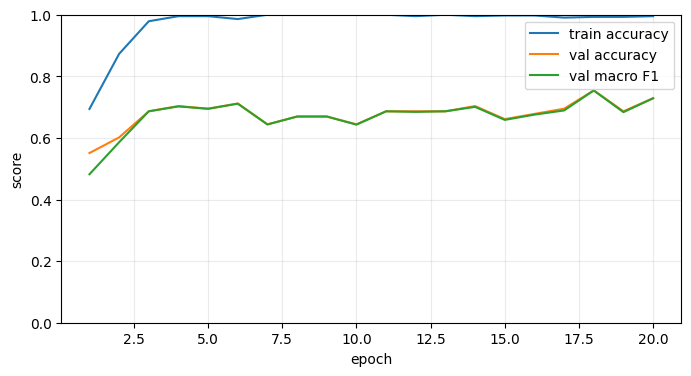

In [8]:
display(history_df.tail())

plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['task_accuracy'], label='train accuracy')
plt.plot(history_df['epoch'], history_df['val_task_accuracy'], label='val accuracy')
plt.plot(history_df['epoch'], history_df['val_task_f1_macro'], label='val macro F1')
plt.xlabel('epoch')
plt.ylabel('score')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. Final Test Evaluation

In [9]:
try:
    checkpoint = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)

test_metrics, y_true, y_pred, y_score, concept_true, concept_pred = evaluate(model, test_loader, split_name='test')
test_metrics_df = pd.DataFrame([test_metrics])
display(test_metrics_df.T.rename(columns={0: 'value'}))

metrics_path = OUTPUT_DIR / 'test_metrics.csv'
test_metrics_df.to_csv(metrics_path, index=False)
print('Saved test metrics to:', metrics_path)

,value
split,test
loss,1.503372
task_accuracy,0.704433
task_f1_macro,0.704254
task_precision_macro,0.704223
task_recall_macro,0.704422
task_auc,0.759767
neural_accuracy,0.714286
neural_f1_macro,0.71057
neural_precision_macro,0.719059


Saved test metrics to: outputs/covid_ct_med_micn/test_metrics.csv


## 10. Confusion Matrix and Classification Report

,pred_NonCOVID,pred_COVID
true_NonCOVID,74,31
true_COVID,29,69


              precision    recall  f1-score   support

    NonCOVID       0.72      0.70      0.71       105
       COVID       0.69      0.70      0.70        98

    accuracy                           0.70       203
   macro avg       0.70      0.70      0.70       203
weighted avg       0.70      0.70      0.70       203



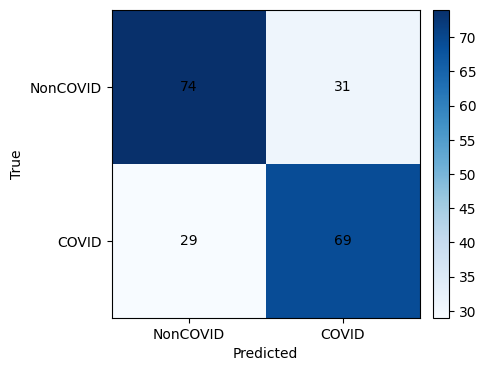

In [10]:
class_names = ['NonCOVID', 'COVID']
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=[f'true_{c}' for c in class_names], columns=[f'pred_{c}' for c in class_names])
display(cm_df)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap='Blues')
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

## 11. Per-Concept Prediction Metrics

In [11]:
concept_rows = []
for idx, name in enumerate(concept_names):
    concept_rows.append({
        'concept': name,
        'positive_rate_true': float(concept_true[:, idx].mean()),
        'positive_rate_pred': float(concept_pred[:, idx].mean()),
        'accuracy': accuracy_score(concept_true[:, idx], concept_pred[:, idx]),
        'f1': f1_score(concept_true[:, idx], concept_pred[:, idx], zero_division=0),
        'precision': precision_score(concept_true[:, idx], concept_pred[:, idx], zero_division=0),
        'recall': recall_score(concept_true[:, idx], concept_pred[:, idx], zero_division=0),
    })

concept_metrics_df = pd.DataFrame(concept_rows).sort_values('f1', ascending=False)
display(concept_metrics_df)
concept_metrics_path = OUTPUT_DIR / 'test_concept_metrics.csv'
concept_metrics_df.to_csv(concept_metrics_path, index=False)
print('Saved concept metrics to:', concept_metrics_path)

,concept,positive_rate_true,positive_rate_pred,accuracy,f1,precision,recall
4,absence of lobar consolidation,0.970443,0.995074,0.965517,0.982456,0.970297,0.994924
6,increased density in the lung,0.694581,1.000000,0.694581,0.819767,0.694581,1.000000
5,localized or diffuse presentation,0.689655,1.000000,0.689655,0.816327,0.689655,1.000000
2,multilobar distribution,0.679803,1.000000,0.679803,0.809384,0.679803,1.000000
0,peripheral ground glass opacities,0.581281,0.995074,0.576355,0.731250,0.579208,0.991525
1,bilateral involvement,0.581281,0.852217,0.610837,0.728522,0.612717,0.898305
7,ground glass appearance,0.669951,0.640394,0.635468,0.721805,0.738462,0.705882
3,crazy paving pattern,0.078818,0.000000,0.921182,0.000000,0.000000,0.000000


Saved concept metrics to: outputs/covid_ct_med_micn/test_concept_metrics.csv


## 12. Neural-Symbolic Explanations

In [14]:
@torch.no_grad()
def collect_explanations(model, loader, max_batches=1):
    model.eval()
    local_examples = []
    global_examples = []
    for batch_idx, (paths, images, labels, concepts) in enumerate(loader):
        images = images.to(DEVICE)
        _, task_logits, neural_probs, concept_embeddings, concept_probs, concept_task_logits = model(images)
        local = model.task_predictor_neural.explain(
            concept_embeddings,
            concept_probs,
            mode='local',
            concept_names=concept_names,
            class_names=class_names,
        )
        global_ = model.task_predictor_neural.explain(
            concept_embeddings,
            concept_probs,
            mode='global',
            concept_names=concept_names,
            class_names=class_names,
        )
        local_examples.extend(local)
        global_examples.extend(global_)
        if batch_idx + 1 >= max_batches:
            break
    return local_examples, global_examples

local_explanations, global_explanations = collect_explanations(
    model,
    test_loader,
    max_batches=2
)

print("Local explanations:")
local_df = pd.DataFrame(local_explanations)
display(local_df.head(20))

print("Global explanation counts from sampled test batches:")
global_df = pd.DataFrame(global_explanations)

print("Global rows:", len(global_df))
print("Global columns:", list(global_df.columns))

if not global_df.empty and {"class", "count"}.issubset(global_df.columns):
    display(
        global_df
        .sort_values(["class", "count"], ascending=[True, False])
        .head(20)
    )
else:
    print("No global explanations were generated for these sampled batches.")
    print("Reason: local explanations show class = -1, meaning no class passed the explanation threshold.")
    display(global_df)

Local explanations:


,class,explanation,attention
0,-1,,[]
1,-1,,[]
2,-1,,[]
3,-1,,[]
4,-1,,[]
5,-1,,[]
6,-1,,[]
7,-1,,[]
8,-1,,[]
9,-1,,[]


Global explanation counts from sampled test batches:
Global rows: 0
Global columns: []
No global explanations were generated for these sampled batches.
Reason: local explanations show class = -1, meaning no class passed the explanation threshold.


""


## 13. Saved Outputs

In [15]:
summary = {
    'best_checkpoint': str(best_ckpt_path),
    'training_history_csv': str(history_path),
    'test_metrics_csv': str(metrics_path),
    'test_concept_metrics_csv': str(concept_metrics_path),
    'test_metrics': test_metrics,
}
summary_path = OUTPUT_DIR / 'run_summary.json'
def json_default(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    return str(value)

summary_path.write_text(json.dumps(summary, indent=2, default=json_default), encoding='utf-8')
print(json.dumps(summary, indent=2, default=json_default))

{
  "best_checkpoint": "outputs/covid_ct_med_micn/best_model.pt",
  "training_history_csv": "outputs/covid_ct_med_micn/training_history.csv",
  "test_metrics_csv": "outputs/covid_ct_med_micn/test_metrics.csv",
  "test_concept_metrics_csv": "outputs/covid_ct_med_micn/test_concept_metrics.csv",
  "test_metrics": {
    "split": "test",
    "loss": 1.5033718175612962,
    "task_accuracy": 0.7044334975369458,
    "task_f1_macro": 0.7042540792540792,
    "task_precision_macro": 0.7042233009708738,
    "task_recall_macro": 0.704421768707483,
    "task_auc": 0.7597667638483965,
    "neural_accuracy": 0.7142857142857143,
    "neural_f1_macro": 0.7105703048180925,
    "neural_precision_macro": 0.7190586575287241,
    "neural_recall_macro": 0.7112244897959183,
    "neural_auc": 0.7458697764820214,
    "concept_accuracy": 0.7216748768472906,
    "concept_f1_micro": 0.7216748768472906,
    "concept_f1_macro": 0.659051724137931
  }
}
